Fractional bandwidth: 0.09655212419159323
Fractional bandwidth: 0.09655212419159323
Fractional bandwidth: 0.1027882360899125
Fractional bandwidth: 0.1027882360899125
Fractional bandwidth: 0.09655212419159323
Fractional bandwidth: 0.09655212419159323
Fractional bandwidth: 0.1027882360899125
Fractional bandwidth: 0.1027882360899125
Fractional bandwidth: 0.09655212419159323
Fractional bandwidth: 0.09655212419159323


/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/dust_extinction/helpers.py:12: SpectralUnitsWarning: x has no units, assuming x units are inverse microns
  warnings.warn(
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/dust_extinction/helpers.py:12: SpectralUnitsWarning: x has no units, assuming x units are inverse microns
  warnings.warn(
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/dust_extinction/helpers.py:12: SpectralUnitsWarning: x has no units, assuming x units are inverse microns
  warnings.warn(
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/dust_extinction/helpers.py:12: SpectralUnitsWarning: x has no units, assuming x units are inverse microns
  warnings.warn(


Fractional bandwidth: 0.1027882360899125
Fractional bandwidth: 0.1027882360899125
Fractional bandwidth: 0.09655212419159323
Fractional bandwidth: 0.09655212419159323
Fractional bandwidth: 0.1027882360899125
Fractional bandwidth: 0.1027882360899125
Fractional bandwidth: 0.09655212419159323
Fractional bandwidth: 0.09655212419159323
Fractional bandwidth: 0.1027882360899125
Fractional bandwidth: 0.1027882360899125


/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/dust_extinction/helpers.py:12: SpectralUnitsWarning: x has no units, assuming x units are inverse microns
  warnings.warn(


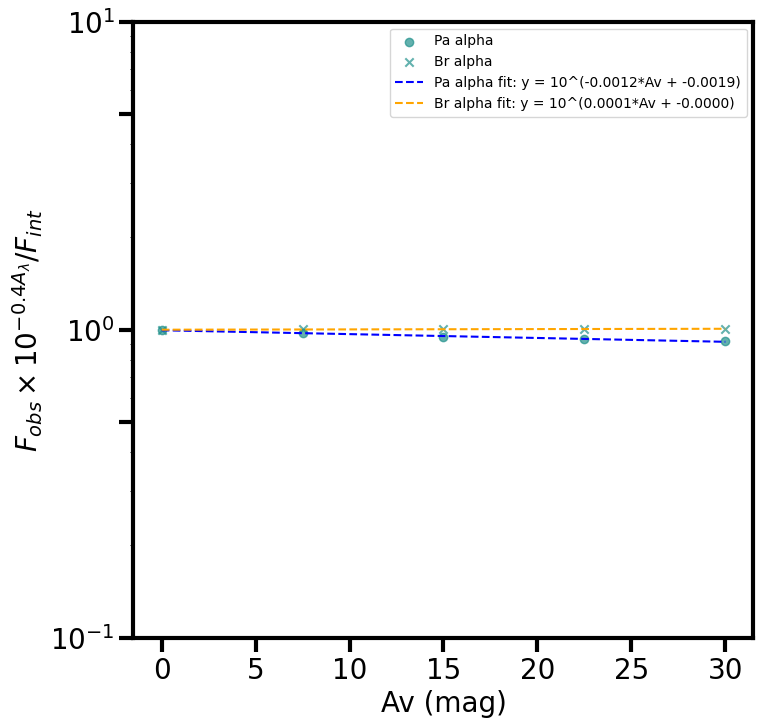

In [1]:
# make blackbody models with different tempearture and also models attenuated by dust extinction with various Av values
import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u
from astropy import constants as const
from astropy.modeling import models
from astropy.modeling import fitting
from dust_extinction.averages import RL85_MWGC, G21_MWAvg, CT06_MWLoc
from dust_extinction.parameter_averages import CCM89
from astroquery.svo_fps import SvoFps
from scipy.optimize import curve_fit

import matplotlib as mpl

plt.rcParams['axes.labelsize']=20 
plt.rcParams['xtick.labelsize']=20
plt.rcParams['ytick.labelsize']=20
plt.rcParams['axes.titlesize']=20
mpl.rcParams['axes.linewidth'] = 3
plt.rcParams['xtick.major.size'] = 10
plt.rcParams['xtick.major.width'] = 3
plt.rcParams['ytick.major.size'] = 10
plt.rcParams['ytick.major.width'] = 3
plt.rcParams['font.family'] = 'sans-serif'
def get_flux_ratio(wavelength, sed, narrow, wide):

   

    wavelength_table_narrow = SvoFps.get_transmission_data(f'JWST/NIRCAM.{narrow}')
    wavelength_table_wide = SvoFps.get_transmission_data(f'JWST/NIRCAM.{wide}')

    waves_wide = wavelength_table_wide['Wavelength']
    trans_narrow = np.interp(waves_wide, wavelength_table_narrow['Wavelength'], wavelength_table_narrow['Transmission'])
    trans_wide = wavelength_table_wide['Transmission']

    waves_wide = waves_wide.to(u.micron).value
    # interpolate SED and wavelength to make the same cadence with waves_wide
    data_interpolated = np.interp(waves_wide, wavelength, sed)

    

    data_wide = (trans_wide/trans_wide.max() * data_interpolated).sum()
    data_narrow = (trans_narrow/trans_narrow.max() * data_interpolated).sum()
    
    
    fractional_bandwidth = ( (trans_wide/trans_wide.max()) * (trans_narrow/trans_narrow.max()) ).sum() / (trans_wide/trans_wide.max()).sum()
    print(f'Fractional bandwidth: {fractional_bandwidth}')
    if fractional_bandwidth == 1:
        print("The filters either have no overlap or are identical. Exiting")
        return


    wide_minus_narrow = (data_wide - data_narrow * fractional_bandwidth) / (1-fractional_bandwidth)
    #return wide_minus_narrow

    narrow_minus_wide = data_narrow - wide_minus_narrow

    #F_line = F_narrow - (F_wide * delta_narrow/delta_wide)/ (1-delta_narrow/delta_wide)
    #narrow_minus_wide = (data_narrow - data_wide * fractional_bandwidth) / (1-fractional_bandwidth)
    return np.array(narrow_minus_wide)  # Ensure writable copy
    #fractional_bandwidth = ( (trans_wide/trans_wide.max()) * (trans_narrow/trans_narrow.max()) ).sum() / (trans_wide/trans_wide.max()).sum()





def func(x,a,b):
    return 10**(a*x+b)
ext = CT06_MWLoc()
temperatures = np.linspace(3000, 10000, 5) * u.K
microns = np.linspace(1.3, 10, 1000) * u.micron

cmap = plt.get_cmap('viridis')
Avs = np.linspace(0, 30, 5)

temp = 5000 * u.K
temperatures = [temp]
for temp in temperatures:
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111)
    intrinsic_to_observed_ratio_paa_arr = []
    intrinsic_to_observed_ratio_bra_arr = []
    intrinsic_paa_arr = []
    intrinsic_bra_arr = []
    observed_paa_arr = []
    observed_bra_arr = []
    for Av in Avs:
    
        bb = models.BlackBody(temperature=temp)
        
        flux = bb(microns)
        flux_ext = flux * 10**(-0.4*ext(microns)*Av)
        intrinsic_ratio_paa = get_flux_ratio(microns.value, flux.value, 'f187n', 'f182m')
        observed_ratio_paa = get_flux_ratio(microns.value, flux_ext.value, 'f187n', 'f182m')
        intrinsic_ratio_bra = get_flux_ratio(microns.value, flux.value, 'f405n', 'f410m')
        observed_ratio_bra = get_flux_ratio(microns.value, flux_ext.value, 'f405n', 'f410m')
        intrinsic_to_observed_ratio_paa = intrinsic_ratio_paa / (observed_ratio_paa * 10**(ext(1/1.87) * Av / 2.5))
        intrinsic_to_observed_ratio_bra = intrinsic_ratio_bra / (observed_ratio_bra * 10**(ext(1/4.05) * Av / 2.5))
        intrinsic_to_observed_ratio_paa_arr.append(intrinsic_to_observed_ratio_paa)
        intrinsic_to_observed_ratio_bra_arr.append(intrinsic_to_observed_ratio_bra)
        intrinsic_paa_arr.append(intrinsic_ratio_paa)
        intrinsic_bra_arr.append(intrinsic_ratio_bra)
        observed_paa_arr.append(observed_ratio_paa)
        observed_bra_arr.append(observed_ratio_bra)
    ax.scatter(Avs, 1/np.array(intrinsic_to_observed_ratio_paa_arr), color=cmap(temp.value/10000), alpha=0.7, label='Pa alpha')

    ax.scatter(Avs, 1/ np.array(intrinsic_to_observed_ratio_bra_arr), color=cmap(temp.value/10000), alpha=0.7, marker='x', label='Br alpha')
    # fit the data with func
    popt, pcov = curve_fit(func, Avs, 1/np.array(intrinsic_to_observed_ratio_paa_arr))
    ax.plot(Avs, func(Avs, *popt), color='blue', linestyle='--', label=f'Pa alpha fit: y = 10^({popt[0]:.4f}*Av + {popt[1]:.4f})')
    popt, pcov = curve_fit(func, Avs, 1/np.array(intrinsic_to_observed_ratio_bra_arr))
    ax.plot(Avs, func(Avs, *popt), color='orange', linestyle='--', label=f'Br alpha fit: y = 10^({popt[0]:.4f}*Av + {popt[1]:.4f})')
    ax.set_xlabel('Av (mag)')
    ax.set_yscale('log')
    ax.set_ylabel(r'$F_{obs}\times10^{-0.4A_\lambda}/F_{int}$')
    ax.set_yticks([ 0.1, 0.5, 1, 5, 10,])
    ax.legend()
    #ax.set_title('temp=' + str(temp))
    plt.show()







In [2]:
import os
os.environ["CRDS_PATH"] = os.path.expanduser("~/crds_cache")
os.makedirs(os.environ["CRDS_PATH"], exist_ok=True)

os.environ["CRDS_SERVER_URL"] = "https://jwst-crds.stsci.edu"
os.environ["CRDS_CONTEXT"] = "jwst_1460.pmap"

from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astroquery.svo_fps import SvoFps
from astropy.wcs import WCS
from astropy.io import fits
from dust_extinction.averages import RL85_MWGC, CT06_MWLoc
from dust_extinction.parameter_averages import CCM89

def get_mag(catalog, ww, filtername='f140m' ):
    print(ww.proj_plane_pixel_area())
    
    flux= (catalog['flux_fit_' + filtername] * u.MJy/u.sr * ww.proj_plane_pixel_area()).to(u.Jy)
    eflux_jy = (catalog['flux_err_' + filtername] * u.MJy/u.sr *  ww.proj_plane_pixel_area()).to(u.Jy)

    jfilts = SvoFps.get_filter_list('JWST')
    jfilts.add_index('filterID')
    wav = int(filtername[1:-1])

    zeropoint_ab = 3631 * u.Jy  # Default to AB magnitude zero point
 
    if wav < 500:

        zeropoint_vega = u.Quantity(jfilts.loc[f'JWST/NIRCam.{filtername.upper()}']['ZeroPoint'], u.Jy)
    else:
        zeropoint_vega = u.Quantity(jfilts.loc[f'JWST/MIRI.{filtername.upper()}']['ZeroPoint'], u.Jy)
   
    abmag = -2.5 * np.log10(flux / zeropoint_ab) * u.mag
    abmag_err = 2.5 / np.log(10) * np.abs(eflux_jy / flux) * u.mag

    vegamag = -2.5 * np.log10(flux / zeropoint_vega) * u.mag
    vegamag_err = 2.5 / np.log(10) * np.abs(eflux_jy / flux) * u.mag

    return  vegamag, vegamag_err, abmag, abmag_err



catalog = Table.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/final_catalog_new.fits')
print(catalog.colnames)
nmatch = catalog['nmatch_bands']
catalog = catalog[nmatch>3]
image_filenames ={
    "f140m": "/orange/adamginsburg/jwst/w51/F140M/pipeline/jw06151-o001_t001_nircam_clear-f140m-merged_i2d.fits",
    "f150w": "/orange/adamginsburg/jwst/w51/F150W/pipeline/jw06151-o001_t001_nircam_clear-f150w-merged_i2d.fits",
    "f162m": "/orange/adamginsburg/jwst/w51/F162M/pipeline/jw06151-o001_t001_nircam_clear-f162m-merged_i2d.fits",
    "f182m": "/orange/adamginsburg/jwst/w51/F182M/pipeline/jw06151-o001_t001_nircam_clear-f182m-merged_i2d.fits",
    "f187n": "/orange/adamginsburg/jwst/w51/F187N/pipeline/jw06151-o001_t001_nircam_clear-f187n-merged_i2d.fits",
    "f210m": "/orange/adamginsburg/jwst/w51/F210M/pipeline/jw06151-o001_t001_nircam_clear-f210m-merged_i2d.fits",
    "f335m": "/orange/adamginsburg/jwst/w51/F335M/pipeline/jw06151-o001_t001_nircam_clear-f335m-merged_i2d.fits",
    "f360m": "/orange/adamginsburg/jwst/w51/F360M/pipeline/jw06151-o001_t001_nircam_clear-f360m-merged_i2d.fits",
    "f405n": "/orange/adamginsburg/jwst/w51/F405N/pipeline/jw06151-o001_t001_nircam_clear-f405n-merged_i2d.fits",
    "f410m": "/orange/adamginsburg/jwst/w51/F410M/pipeline/jw06151-o001_t001_nircam_clear-f410m-merged_i2d.fits", # weird, the filename is different from what is downloaded with the STScI pipeline...
    "f480m": "/orange/adamginsburg/jwst/w51/F480M/pipeline/jw06151-o001_t001_nircam_clear-f480m-merged_i2d.fits",
    "f560w": "/orange/adamginsburg/jwst/w51/F560W/pipeline/jw06151-o002_t001_miri_f560w_i2d.fits",
    "f770w": "/orange/adamginsburg/jwst/w51/F770W/pipeline/jw06151-o002_t001_miri_f770w_i2d.fits",
    "f1000w": "/orange/adamginsburg/jwst/w51/F1000W/pipeline/jw06151-o002_t001_miri_f1000w_i2d.fits",
    "f1280w": "/orange/adamginsburg/jwst/w51/F1280W/pipeline/jw06151-o002_t001_miri_f1280w_i2d.fits",
    "f2100w": "/orange/adamginsburg/jwst/w51/F2100W/pipeline/jw06151-o002_t001_miri_f2100w_i2d.fits",
    
}

f140m_header = fits.getheader(image_filenames['f140m'], ext=('SCI', 1))
f162m_header = fits.getheader(image_filenames['f162m'], ext=('SCI', 1))
f182m_header = fits.getheader(image_filenames['f182m'], ext=('SCI', 1))
f210m_header = fits.getheader(image_filenames['f210m'], ext=('SCI', 1))
f335m_header = fits.getheader(image_filenames['f335m'], ext=('SCI', 1))
f360m_header = fits.getheader(image_filenames['f360m'], ext=('SCI', 1))
f405n_header = fits.getheader(image_filenames['f405n'], ext=('SCI', 1))
f410m_header = fits.getheader(image_filenames['f410m'], ext=('SCI', 1))
f480m_header = fits.getheader(image_filenames['f480m'], ext=('SCI', 1))
f560w_header = fits.getheader(image_filenames['f560w'], ext=('SCI', 1))
f770w_header = fits.getheader(image_filenames['f770w'], ext=('SCI', 1))
f1000w_header = fits.getheader(image_filenames['f1000w'], ext=('SCI', 1))
f1280w_header = fits.getheader(image_filenames['f1280w'], ext=('SCI', 1))
f2100w_header = fits.getheader(image_filenames['f2100w'], ext=('SCI', 1))



f140m_mag = get_mag(catalog, WCS(f140m_header), filtername='f140m')
f162m_mag = get_mag(catalog, WCS(f162m_header), filtername='f162m')
f182m_mag = get_mag(catalog, WCS(f182m_header), filtername='f182m')
f210m_mag = get_mag(catalog, WCS(f210m_header), filtername='f210m')
f335m_mag = get_mag(catalog, WCS(f335m_header), filtername='f335m')
f360m_mag = get_mag(catalog, WCS(f360m_header), filtername='f360m')
f405n_mag = get_mag(catalog, WCS(f405n_header), filtername='f405n')
f410m_mag = get_mag(catalog, WCS(f410m_header), filtername='f410m')
f480m_mag = get_mag(catalog, WCS(f480m_header), filtername='f480m')
f560w_mag = get_mag(catalog, WCS(f560w_header), filtername='f560w')
f770w_mag = get_mag(catalog, WCS(f770w_header), filtername='f770w')
f1000w_mag = get_mag(catalog, WCS(f1000w_header), filtername='f1000w')
f1280w_mag = get_mag(catalog, WCS(f1280w_header), filtername='f1280w')
f2100w_mag = get_mag(catalog, WCS(f2100w_header), filtername='f2100w')

f187n_header = fits.getheader(image_filenames['f187n'], ext=('SCI', 1))
f187n_mag = get_mag(catalog, WCS(f187n_header), filtername='f187n')


from dust_extinction.averages import RL85_MWGC, CT06_MWGC
from dust_extinction.parameter_averages import CCM89
import astropy.constants as const

ext = RL85_MWGC()
ext = CT06_MWLoc()
def plot_extvec_cmd(ax, color1, mag1, ext=RL85_MWGC(), extvec_scale=200, start=None,
                    color='y', head_width=0.5, color1_data=None, mag1_data=None, label=None):
    def get_wave(c):
        if c == '410m405': return 4.10*u.um
        if c == '405m410': return 4.05*u.um
        if c == 'Hmag': return 1.634*u.um
        if c == 'Ksmag': return 2.143527*u.um
        return int(c[1:-1])/100*u.um

    w1 = get_wave(color1[0])
    w2 = get_wave(color1[1])
    w3 = get_wave(mag1[0])

    if w1 > w2:
        w1, w2 = w2, w1
        color1 = color1[::-1]
    print(w1,w2,w3)

    # Only plot if all are in valid range
    try:
        e_1 = ext(1/w1) * extvec_scale
        e_2 = ext(1/w2) * extvec_scale
        e_3 = ext(1/w3) * extvec_scale
    except ValueError as e:
        print(f"Extinction vector not plotted: {e}")
        return
    print(w1,w2,w3)
    print(e_1, e_2, e_3)
    if start == None:
        mean_color1 = np.nanmean(color1_data)
        mean_mag1 = np.nanmean(mag1_data)
        std_color1 = np.nanstd(color1_data)
        std_mag1 = np.nanstd(mag1_data)
        if e_1 - e_2 < 0:
            std_color1 *= -1
        
    
        start2 = (mean_color1 + 2*std_color1, mean_mag1 + 2*std_mag1)
    else:
        start2 = start
    
    # Strip units for plotting if present
    if hasattr(start2[0], 'value'):
        start2_x = start2[0].value
        start2_y = start2[1].value
    else:
        start2_x = start2[0]
        start2_y = start2[1]

    ax.annotate(f'$A_V={extvec_scale}$', xy=(start2_x + (e_1 - e_2), start2_y + e_3),
                xytext=(start2_x, start2_y),
                arrowprops=dict(arrowstyle='-|>', color=color,
                                shrinkA=0, shrinkB=0,
                                mutation_scale=20, linewidth=1.5))
    ax.plot([], [], color=color, marker='>', markersize=8,
            label=f'{label}', linestyle='-', linewidth=2)



imgsavedir = '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/plots/cmds/'
filters = {
    'f140m': f140m_mag,
    'f162m': f162m_mag,
    'f182m': f182m_mag,
    'f187n': f187n_mag,
    'f210m': f210m_mag,
    'f335m': f335m_mag,
    'f360m': f360m_mag,
    'f405n': f405n_mag,
    'f410m': f410m_mag,
    'f480m': f480m_mag,
    'f560w': f560w_mag,
    'f770w': f770w_mag,
    'f1000w': f1000w_mag,
    'f1280w': f1280w_mag,
    'f2100w': f2100w_mag,
}
filter_names = list(filters.keys())

def get_line_excess(catalog, narrow, wide):
    # --- Convert catalog MJy/sr → Jy ---
    ww_narrow = WCS(fits.getheader(image_filenames[narrow], ext=('SCI', 1)))
    ww_wide = WCS(fits.getheader(image_filenames[wide], ext=('SCI', 1)))

    data_narrow = (catalog['flux_fit_' + narrow] * u.MJy/u.sr *
                   ww_narrow.proj_plane_pixel_area()).to(u.Jy)
    data_wide = (catalog['flux_fit_' + wide] * u.MJy/u.sr *
                 ww_wide.proj_plane_pixel_area()).to(u.Jy)

    # --- Load filter curves ---
    tab_n = SvoFps.get_transmission_data(f'JWST/NIRCAM.{narrow}')
    tab_w = SvoFps.get_transmission_data(f'JWST/NIRCAM.{wide}')
    print('wavelength', tab_n['Wavelength'], tab_w['Wavelength'])
    wave_n = tab_n['Wavelength'] * u.AA
    trans_n = tab_n['Transmission']

    wave_w = tab_w['Wavelength'] * u.AA
    trans_w = tab_w['Transmission']

    # --- Interpolate narrow onto wide grid ---
    trans_n_interp = np.interp(wave_w.value, wave_n.value, trans_n)

    # --- Fractional overlap (proper integral) ---
    num = np.trapezoid(
    (trans_w / trans_w.max()) * (trans_n_interp / trans_n.max()),
    wave_w.value
    )
    den = np.trapezoid(trans_w / trans_w.max(), wave_w.value)
    f = num / den

    if np.isclose(f, 1.0):
        return None, None

    # --- Continuum & line (still in Jy = F_nu) ---
    cont_nu = (data_wide - data_narrow * f) / (1 - f)
    line_nu = data_narrow - cont_nu

    width_narrow = np.trapezoid(trans_n / trans_n.max(), wave_n.value) * u.AA

    # --- Equivalent Width ---
    with np.errstate(divide='ignore', invalid='ignore'):
        ew = (line_nu / cont_nu) * width_narrow

    return line_nu.value, ew.to_value(u.AA)

def get_line_excess_BBscaling(catalog, narrow, wide):
    #with blackbody scaling
    # --- Convert catlog MJy/sr → Jy ---
    bb = models.BlackBody(temperature=5000 * u.K)
    ww_narrow = WCS(fits.getheader(image_filenames[narrow], ext=('SCI', 1)))
    ww_wide = WCS(fits.getheader(image_filenames[wide], ext=('SCI', 1)))

    data_narrow = (catalog['flux_fit_' + narrow] * u.MJy/u.sr *
                   ww_narrow.proj_plane_pixel_area()).to(u.Jy)
    data_wide = (catalog['flux_fit_' + wide] * u.MJy/u.sr *
                 ww_wide.proj_plane_pixel_area()).to(u.Jy)

    # --- Load filter curves ---
    tab_n = SvoFps.get_transmission_data(f'JWST/NIRCAM.{narrow}')
    tab_w = SvoFps.get_transmission_data(f'JWST/NIRCAM.{wide}')
    print('wavelength', tab_n['Wavelength'], tab_w['Wavelength'])
    wave_n = tab_n['Wavelength'] * u.AA
    trans_n = tab_n['Transmission']

    wave_w = tab_w['Wavelength'] * u.AA
    trans_w = tab_w['Transmission']

    # --- Interpolate narrow onto wide grid ---
    trans_n_interp = np.interp(wave_w.value, wave_n.value, trans_n)

    # --- Fractional overlap (proper integral) ---
    num = np.trapezoid(
     (trans_n_interp / trans_n.max()) * bb(wave_w),
    wave_w.value
    )
    den = np.trapezoid(trans_w / trans_w.max() * bb(wave_w) , wave_w.value)
    f = num / den

    if np.isclose(f, 1.0):
        return None, None

    # --- Continuum & line (still in Jy = F_nu) ---
    cont_nu = (data_wide - data_narrow * f) / (1 - f)
    line_nu = data_narrow - cont_nu

    width_narrow = np.trapezoid(trans_n / trans_n.max(), wave_n.value) * u.AA

    # --- Equivalent Width ---
    with np.errstate(divide='ignore', invalid='ignore'):
        ew = (line_nu / cont_nu) * width_narrow

    return line_nu.value, ew.to_value(u.AA)

paa_excess,  paa_excess_ew = get_line_excess(catalog, 'f187n', 'f182m')
bra_excess,  bra_excess_ew = get_line_excess(catalog, 'f405n', 'f410m')

print('paa_excess', paa_excess)



['skycoord_ref', 'skycoord_ref_filtername', 'sep_f140m', 'id_f140m', 'skycoord_f140m', 'flux_fit_f140m', 'flux_err_f140m', 'mask_f140m', 'qfit_f140m', 'cfit_f140m', 'local_bkg_f140m', 'roundness1_f140m', 'roundness2_f140m', 'sharpness_f140m', 'from_sat_catalog_f140m', 'std_ra_f140m', 'std_dec_f140m', 'nmatch_f140m', 'nmatch_good_f140m', 'flux_err_prop_f140m', 'sep_f162m', 'id_f162m', 'skycoord_f162m', 'flux_fit_f162m', 'flux_err_f162m', 'mask_f162m', 'qfit_f162m', 'cfit_f162m', 'local_bkg_f162m', 'roundness1_f162m', 'roundness2_f162m', 'sharpness_f162m', 'from_sat_catalog_f162m', 'std_ra_f162m', 'std_dec_f162m', 'nmatch_f162m', 'nmatch_good_f162m', 'flux_err_prop_f162m', 'sep_f182m', 'id_f182m', 'skycoord_f182m', 'flux_fit_f182m', 'flux_err_f182m', 'mask_f182m', 'qfit_f182m', 'cfit_f182m', 'local_bkg_f182m', 'roundness1_f182m', 'roundness2_f182m', 'sharpness_f182m', 'from_sat_catalog_f182m', 'std_ra_f182m', 'std_dec_f182m', 'nmatch_f182m', 'nmatch_good_f182m', 'flux_err_prop_f182m', 's

Set DATE-AVG to '2025-05-06T16:59:22.406' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: invalid value encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
Set DATE-AVG to '2025-05-06T14:19:06.870' from MJD-AVG.
Set DATE-END to '2025-05-06T14:41:02.194' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.220336 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610512569.543 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: invalid value encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
Set DATE-AVG to '2025-05-0

7.525093724479512e-11 deg2
7.52790883669383e-11 deg2
7.52510476872822e-11 deg2
7.52514718037244e-11 deg2


Set DATE-AVG to '2025-05-06T14:19:01.510' from MJD-AVG.
Set DATE-END to '2025-05-06T14:41:02.130' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.220310 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610512065.053 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: invalid value encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
Set DATE-AVG to '2025-05-06T15:11:59.611' from MJD-AVG.
Set DATE-END to '2025-05-06T15:35:36.878' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.237189 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610816321.821 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: invalid value encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
Set DATE-AVG to '2025-05-0

3.053877779107583e-10 deg2
3.0536898714608487e-10 deg2
3.056563930691893e-10 deg2
3.0541063885182936e-10 deg2


...

Set DATE-AVG to '2024-09-08T11:47:44.336' from MJD-AVG.
Set DATE-END to '2024-09-08T13:00:37.070' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    -3.791203 from OBSGEO-[XYZ].
Set OBSGEO-H to 1291801554.144 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2024-09-08T11:55:48.768' from MJD-AVG.
Set DATE-END to '2024-09-08T13:08:42.701' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    -3.785099 from OBSGEO-[XYZ].
Set OBSGEO-H to 1291756623.231 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


9.491652069110604e-10 deg2
9.491651972183757e-10 deg2


Set DATE-AVG to '2025-05-06T13:24:26.762' from MJD-AVG.
Set DATE-END to '2025-05-06T13:48:04.085' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.202551 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610191901.140 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: invalid value encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
Set DATE-AVG to '2025-05-06T13:24:26.762' from MJD-AVG.
Set DATE-END to '2025-05-06T13:48:04.085' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.202551 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610191901.140 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-05-06T15:11:59.611' from MJD-AVG.
Set DATE-END to '2025-05-06T15:35:36.878' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.237189 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610816321.821 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '

7.524574264515582e-11 deg2
wavelength Wavelength
 Angstrom 
----------
   18342.0
   18352.0
   18362.0
   18372.0
   18382.0
   18392.0
   18402.0
   18412.0
   18422.0
       ...
   19042.0
   19052.0
   19062.0
   19072.0
   19082.0
   19092.0
   19102.0
   19112.0
   19122.0
   19132.0
Length = 80 rows Wavelength
 Angstrom 
----------
   16635.0
   16645.0
   16655.0
   16665.0
   16675.0
   16685.0
   16695.0
   16705.0
   16715.0
       ...
   20355.0
   20365.0
   20375.0
   20385.0
   20395.0
   20405.0
   20415.0
   20425.0
   20435.0
   20445.0
Length = 382 rows
wavelength Wavelength
 Angstrom 
----------
   39699.2
   39712.7
   39726.2
   39739.7
   39753.2
   39766.7
   39780.3
   39793.8
   39807.3
       ...
   41239.6
   41253.1
   41266.6
   41280.1
   41293.6
   41307.1
   41320.7
   41334.2
   41347.7
   41361.2
Length = 124 rows Wavelength
 Angstrom 
----------
   36740.0
   36753.5
   36767.0
   36780.5
   36794.0
   36807.5
   36821.1
   36834.6
   36848.1
       

Set DATE-AVG to '2025-05-06T16:06:02.828' from MJD-AVG.
Set DATE-END to '2025-05-06T16:29:39.435' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.254571 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611129611.449 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


 col1    col2  col3      col4          col5       col6   col7   col8   col9  col10 col11 col12   col13  col14  col15  col16  col17  col18   col19   col20   col21   col22    col23     col24     col25   col26   col27   col28   col29   col30   col31   col32   col33   col34   col35   col36   col37   col38   col39   col40   col41   col42   col43   col44   col45   col46   col47   col48   col49   col50 
------ ------- ---- -------------- ------------ ------- ------ ------ ------ ----- ----- ------ ------- ------ ------ ------ ------ ----- --------- ----- --------- ------ --------- --------- --------- ------ ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- -------
0.0207 0.15867  5.0   0.0908484459 1.0897678296   0.091  -0.78 3.4382  2.881     0   0.0  0.545     0.0    0.0    0.0    0.0    0.0    -1 -2.54e-13   0.0    0.6936 0.2855  0.003749  0.001011  0.009172

/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/dust_extinction/helpers.py:12: SpectralUnitsWarning: x has no units, assuming x units are inverse microns
  warnings.warn(


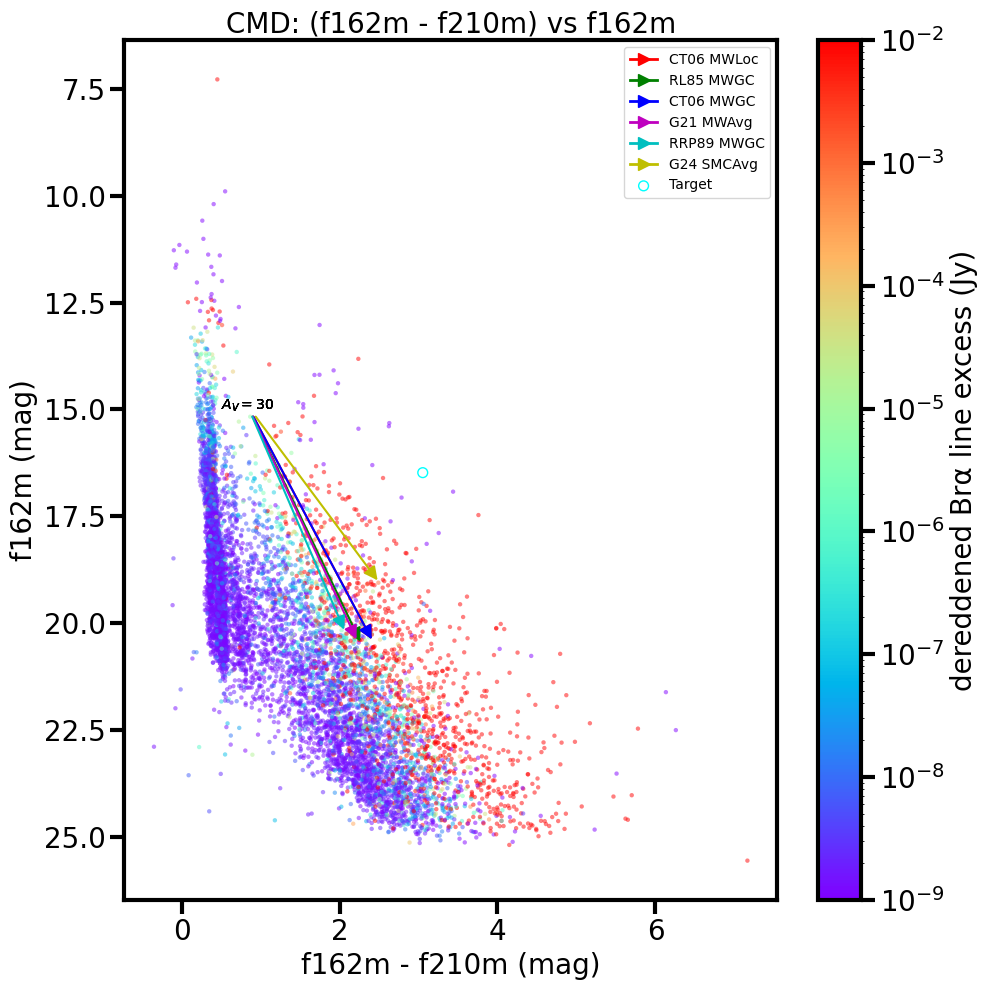

In [3]:
def get_av(color, mag, ext=CT06_MWLoc(), color1=('f140m', 'f162m'), mag1=('f140m',), isochrone_line_params=None):
    # Get the slope and intercept of the isochrone line
    m_iso, b_iso = isochrone_line_params
    print('color1:', color1, 'mag1:', mag1)

    # Get the extinction vector components
    w_color1_1 = int(color1[0][1:-1])/100*u.um
    w_color1_2 = int(color1[1][1:-1])/100*u.um
    w_mag1 = int(mag1[0][1:-1])/100*u.um
    print('w_color1_1:', w_color1_1, 'w_color1_2:', w_color1_2, 'w_mag1:', w_mag1)

    e_color1_1 = ext(1/w_color1_1)
    e_color1_2 = ext(1/w_color1_2)
    e_mag1 = ext(1/w_mag1)

    # get the contact to the isochrone line along the extinction vector
    # the extinction vector can be represented as a line with slope m_ext = e_mag1 / (e_color1_1 - e_color1_2) and passing through the point (color, mag)
    m_ext = e_mag1 / (e_color1_1 - e_color1_2)
    b_ext = mag - m_ext * color

    # find the intersection of the isochrone line and the extinction vector
    x_int = (b_ext - b_iso) / (m_iso - m_ext)
    y_int = m_iso * x_int + b_iso

    # calculate A_V as the distance from (color, mag) to (x_int, y_int) along the extinction vector
    av = (mag - y_int) / ext(1/w_mag1)
    av[av < 0] = 0
    return av
parsec_av0 = Table.read('/home/t.yoo/parsec_av0.txt', format='ascii')
parsec_av0.pprint(max_width=-1, max_lines=-1)   
m_init = parsec_av0['col4']  
parsec_av0 = parsec_av0[m_init<300]              
logage_av0 = parsec_av0['col3']
mass_av0 = parsec_av0['col6']
print(np.min(m_init), np.max(m_init))
print(np.min(mass_av0), np.max(mass_av0))
F140Mmag_av0 = parsec_av0['col39'] + 5*np.log10(5400)-5
F162Mmag_av0 = parsec_av0['col40']+ 5*np.log10(5400)-5
F182Mmag_av0 = parsec_av0['col41']+ 5*np.log10(5400)-5
F210Mmag_av0 = parsec_av0['col42']+ 5*np.log10(5400)-5
F335Mmag_av0 = parsec_av0['col45']+ 5*np.log10(5400)-5
F360Mmag_av0 = parsec_av0['col46']+ 5*np.log10(5400)-5
F410Mmag_av0 = parsec_av0['col47']+ 5*np.log10(5400)-5
F480Mmag_av0 = parsec_av0['col50']+ 5*np.log10(5400)-5
parsec_mags = {
    'f140m': F140Mmag_av0,
    'f162m': F162Mmag_av0,
    'f182m': F182Mmag_av0,
    'f210m': F210Mmag_av0,
    'f335m': F335Mmag_av0,
    'f360m': F360Mmag_av0,
    'f410m': F410Mmag_av0,
    'f480m': F480Mmag_av0,
}

f162 = f162m_mag[0].to_value(u.mag)
f210 = f210m_mag[0].to_value(u.mag)
f360 = f360m_mag[0].to_value(u.mag)
f480 = f480m_mag[0].to_value(u.mag)
age_idx = logage_av0 == 6
idx_01msun = np.argmin(np.abs(mass_av0[age_idx]-0.1))
idx_20msun = np.argmin(np.abs(mass_av0[age_idx]-20))
isochrone_x_start = parsec_mags['f162m'][age_idx][idx_01msun] - parsec_mags['f210m'][age_idx][idx_01msun]
isochrone_x_end = parsec_mags['f162m'][age_idx][idx_20msun] - parsec_mags['f210m'][age_idx][idx_20msun]
isochrone_y_start = parsec_mags['f162m'][age_idx][idx_01msun]
isochrone_y_end = parsec_mags['f162m'][age_idx][idx_20msun]

color_slope = (isochrone_y_end - isochrone_y_start) / (isochrone_x_end - isochrone_x_start)
color_intercept = isochrone_y_start - color_slope * isochrone_x_start
av_estimate = get_av(f162 - f210, f162, ext=CT06_MWLoc(), color1=('f162m', 'f210m'), mag1=('f162m',), isochrone_line_params=(color_slope, color_intercept))
bra_excess_dered = bra_excess * 10**(0.4*ext(1/4.05)*av_estimate)
paa_excess_dered = paa_excess * 10**(0.4*ext(1/1.87)*av_estimate)

from astropy.coordinates import SkyCoord
from matplotlib.colors import LogNorm
ext = CT06_MWLoc()
# plot f140m-f162m color coded by f405n-f410m color
color = filters['f162m'][0] - filters['f210m'][0]
color_for_points = bra_excess_dered

magnitude = filters['f162m'][0]


# Create plot
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)

#hb = ax.hexbin(color_valid, mag_valid, gridsize=100, cmap='inferno', mincnt=1, bins='log')
#cb = fig.colorbar(hb, ax=ax, label='log(N)')
cmap = plt.get_cmap('rainbow')

ax.scatter(color.value, magnitude.value, s=10, c=color_for_points, cmap=cmap, alpha=0.5, edgecolor='none',vmin=np.nanpercentile(color_for_points, 10), vmax=np.nanpercentile(color_for_points, 90))
ax.set_xlabel('f162m - f210m (mag)')
ax.set_ylabel('f162m (mag)')
ax.set_title(f'CMD: (f162m - f210m) vs f162m')
ax.invert_yaxis()  # Invert y-axis for magnitude
from dust_extinction.averages import RL85_MWGC, CT06_MWLoc, G21_MWAvg,RRP89_MWGC, G24_SMCAvg
colorlist = ['r', 'g', 'b', 'm', 'c', 'y']
for ext_model, labels, c in zip([CT06_MWLoc(), RL85_MWGC(), CT06_MWGC(), G21_MWAvg(), RRP89_MWGC(), G24_SMCAvg()], ['CT06 MWLoc', 'RL85 MWGC', 'CT06 MWGC', 'G21 MWAvg', 'RRP89 MWGC', 'G24 SMCAvg'], colorlist):
    plot_extvec_cmd(ax, color1=('f162m', 'f210m'), mag1=('f162m',), 
                     ext=ext_model, extvec_scale=30, color=c, 
                     color1_data=color, mag1_data=magnitude, start=(0.5, 15), label=labels)
  



#add colorbar for the color coding
norm = LogNorm(vmin=1e-9, vmax=1e-2)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('dereddened Brα line excess (Jy)')
plt.tight_layout()
#plt.savefig(f'{imgsavedir}cmd_{f1}_{f2}_vs_{mag_filter}.png', dpi=150)

skycoord_target = SkyCoord(ra=290.924875*u.deg, dec=14.5102237*u.deg, frame='icrs')
idx, d2d, _ = skycoord_target.match_to_catalog_sky(catalog['skycoord_ref'], nthneighbor=1)

ax.scatter(color[idx].value, magnitude[idx].value, s=50, edgecolor='cyan', facecolor='none', marker='o', label='Target')
ax.legend()


plt.show()

1.62 um 2.1 um 1.62 um
1.62 um 2.1 um 1.62 um
5.382330074074073 3.4739712 5.382330074074073
1.62 um 2.1 um 1.62 um
1.62 um 2.1 um 1.62 um
5.4357638888888875 3.6726315789473687 5.4357638888888875
1.62 um 2.1 um 1.62 um
1.62 um 2.1 um 1.62 um
5.382330074074073 3.4739712 5.382330074074073
1.62 um 2.1 um 1.62 um
1.62 um 2.1 um 1.62 um
5.377005929042962 3.662529750810622 5.377005929042962
1.62 um 2.1 um 1.62 um
1.62 um 2.1 um 1.62 um
5.15745734947461 3.598397287717673 5.15745734947461
1.62 um 2.1 um 1.62 um
1.62 um 2.1 um 1.62 um
4.00178720911646 2.019610371795196 4.00178720911646


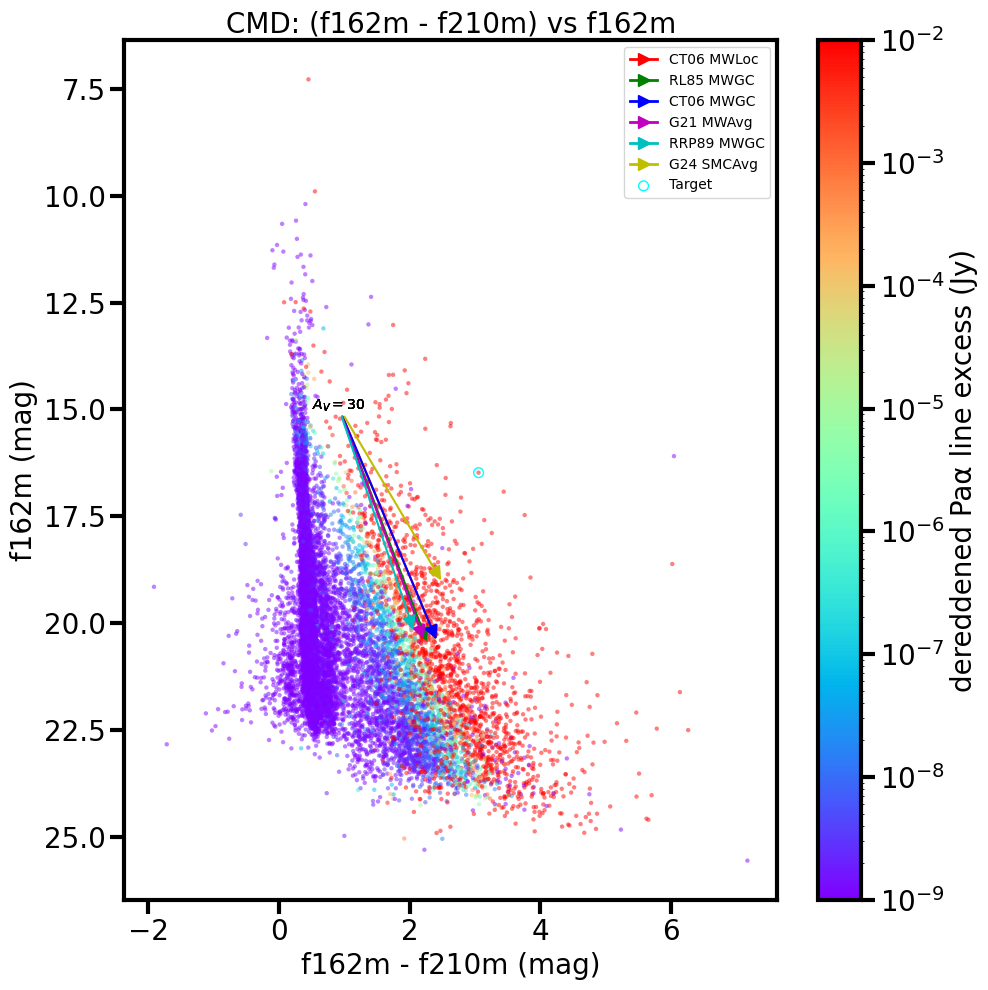

In [4]:
# paa
color_for_points = paa_excess_dered

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)

#hb = ax.hexbin(color_valid, mag_valid, gridsize=100, cmap='inferno', mincnt=1, bins='log')
#cb = fig.colorbar(hb, ax=ax, label='log(N)')
cmap = plt.get_cmap('rainbow')

ax.scatter(color.value, magnitude.value, s=10, c=color_for_points, cmap=cmap, alpha=0.5, edgecolor='none',vmin=np.nanpercentile(color_for_points, 10), vmax=np.nanpercentile(color_for_points, 90))
ax.set_xlabel('f162m - f210m (mag)')
ax.set_ylabel('f162m (mag)')
ax.set_title(f'CMD: (f162m - f210m) vs f162m')
ax.invert_yaxis()  # Invert y-axis for magnitude
from dust_extinction.averages import RL85_MWGC, CT06_MWLoc, G21_MWAvg,RRP89_MWGC, G24_SMCAvg
colorlist = ['r', 'g', 'b', 'm', 'c', 'y']
for ext_model, labels, c in zip([CT06_MWLoc(), RL85_MWGC(), CT06_MWGC(), G21_MWAvg(), RRP89_MWGC(), G24_SMCAvg()], ['CT06 MWLoc', 'RL85 MWGC', 'CT06 MWGC', 'G21 MWAvg', 'RRP89 MWGC', 'G24 SMCAvg'], colorlist):
    plot_extvec_cmd(ax, color1=('f162m', 'f210m'), mag1=('f162m',), 
                     ext=ext_model, extvec_scale=30, color=c, 
                     color1_data=color, mag1_data=magnitude, start=(0.5, 15), label=labels)
  



#add colorbar for the color coding
norm = LogNorm(vmin=1e-9, vmax=1e-2)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('dereddened Paα line excess (Jy)')
plt.tight_layout()
#plt.savefig(f'{imgsavedir}cmd_{f1}_{f2}_vs_{mag_filter}.png', dpi=150)

skycoord_target = SkyCoord(ra=290.924875*u.deg, dec=14.5102237*u.deg, frame='icrs')
idx, d2d, _ = skycoord_target.match_to_catalog_sky(catalog['skycoord_ref'], nthneighbor=1)

ax.scatter(color[idx].value, magnitude[idx].value, s=50, edgecolor='cyan', facecolor='none', marker='o', label='Target')
ax.legend()










In [5]:
dd

NameError: name 'dd' is not defined

In [ ]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel

# ----------------------------------
# Your data (replace with yours)
# ----------------------------------
# X should be (N, 2) for 2D input
X = np.array([
    [x1, y1],
    [x2, y2],
    ...
])

# target values (N,)
z = np.array([z1, z2, ...])

# ----------------------------------
# Define kernel
# ----------------------------------
kernel = (
    ConstantKernel(1.0, (1e-3, 1e3)) *
    RBF(length_scale=[1.0, 1.0], length_scale_bounds=(1e-2, 1e2)) +
    WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-8, 1e-1))
)

# ----------------------------------
# Fit GPR
# ----------------------------------
gpr = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10,
    normalize_y=True
)

gpr.fit(X, z)

# ----------------------------------
# Prediction (interpolation + mild extrapolation)
# ----------------------------------
# Example grid
x_test = np.linspace(xmin, xmax, 100)
y_test = np.linspace(ymin, ymax, 100)
xx, yy = np.meshgrid(x_test, y_test)

X_test = np.column_stack([xx.ravel(), yy.ravel()])

z_pred, z_std = gpr.predict(X_test, return_std=True)

# reshape back to grid
z_pred = z_pred.reshape(xx.shape)
z_std = z_std.reshape(xx.shape)

NameError: name 'x1' is not defined